<a href="https://colab.research.google.com/github/FusRaDa/biot670i_capstone_vaccination_project/blob/kalkidan-analysis-engine/perin_notebooks/analysis_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


This notebook is an initial prototype of the statistical analysis engine for the BIOT 670I Vaccination Project. The current dataset is illustrative test data used to develop and validate the analysis workflow.  Planned analyses include baseline correlation, time-lagged associations, fixed-effects modeling, and uncertainty assessment.

In [2]:
# BIOT 670I Capstone - Vaccination Project
# Analysis Engine
# Kalkidan Perin



import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf

print("Analysis environment ready.")

Analysis environment ready.


In [3]:

data = {
    "state": [
        "WA", "WA", "WA", "WA", "WA",
        "OR", "OR", "OR", "OR", "OR",
        "CA", "CA", "CA", "CA", "CA"
    ],

    "year": [
        2018, 2019, 2020, 2021, 2022,
        2018, 2019, 2020, 2021, 2022,
        2018, 2019, 2020, 2021, 2022
    ],

    "vaccination_coverage": [
        91.5, 91.0, 90.4, 89.8, 89.1,
        93.0, 92.7, 92.1, 91.6, 91.0,
        95.0, 94.8, 94.5, 94.2, 93.9
    ],

    "incidence_per_100k": [
        1.0, 1.2, 1.5, 2.0, 2.5,
        0.7, 0.8, 1.0, 1.3, 1.7,
        0.3, 0.4, 0.5, 0.6, 0.8
    ]
}

df = pd.DataFrame(data)

df

,state,year,vaccination_coverage,incidence_per_100k
0,WA,2018,91.5,1.0
1,WA,2019,91.0,1.2
2,WA,2020,90.4,1.5
3,WA,2021,89.8,2.0
4,WA,2022,89.1,2.5
5,OR,2018,93.0,0.7
6,OR,2019,92.7,0.8
7,OR,2020,92.1,1.0
8,OR,2021,91.6,1.3
9,OR,2022,91.0,1.7


In [4]:
# checking structure and quality of the dataset

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of unique states:")
print(df["state"].nunique())

print("\nYear range:")
print(df["year"].min(), "-", df["year"].max())

Dataset shape: (15, 4)

Column names:
['state', 'year', 'vaccination_coverage', 'incidence_per_100k']

Data types:
state                    object
year                      int64
vaccination_coverage    float64
incidence_per_100k      float64
dtype: object

Missing values:
state                   0
year                    0
vaccination_coverage    0
incidence_per_100k      0
dtype: int64

Number of unique states:
3

Year range:
2018 - 2022


 https://support.minitab.com/en-us/minitab/help-and-how-to/statistics/basic-statistics/supporting-topics/correlation-and-covariance/a-comparison-of-the-pearson-and-spearman-correlation-methods/$0

Pearson Correlation
Best use: Continuous variables with an approximately linear relationship.
Pattern type: Linear relationships.
Sensitivity: Can be strongly affected by outliers.
Statistical inference typically assumes conditions such as approximate bivariate normality.


Spearman Correlation
Best use: Ordinal data, ranked lists, or skewed continuous data.
Pattern type: Monotonic relationships (values consistently increase or decrease together).
Sensitivity: Highly robust against extreme outliers
Data shape: It does not require a normal distribution.


In [5]:
# Baseline correlation analysis
# Examines the association between vaccination coverage

pearson_r, pearson_p = pearsonr(
    df["vaccination_coverage"],
    df["incidence_per_100k"]
)


spearman_r, spearman_p = spearmanr(
    df["vaccination_coverage"],
    df["incidence_per_100k"]
)

print("BASELINE CORRELATION RESULTS")
print("----------------------------")

print(f"Pearson correlation:  r = {pearson_r:.3f}")
print(f"Pearson p-value:          {pearson_p:.4f}")

print(f"\nSpearman correlation: ρ = {spearman_r:.3f}")
print(f"Spearman p-value:          {spearman_p:.4f}")


BASELINE CORRELATION RESULTS
----------------------------
Pearson correlation:  r = -0.941
Pearson p-value:          0.0000

Spearman correlation: ρ = -0.972
Spearman p-value:          0.0000


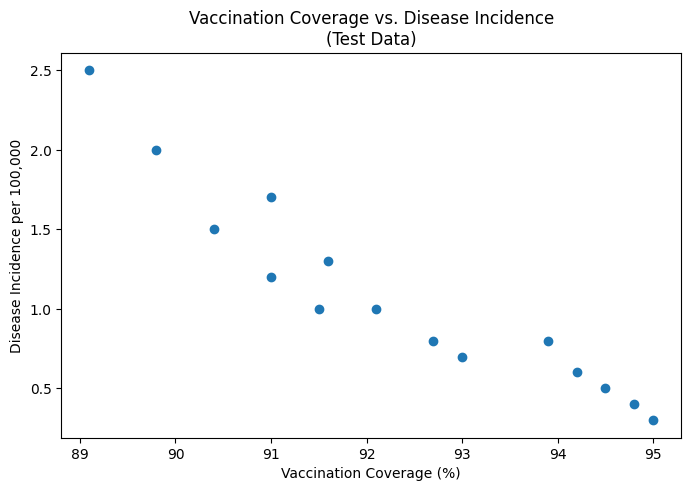

In [6]:
# Visualize the baseline relationship
# NOTE: Current data are illustrative test data only.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["vaccination_coverage"],
    df["incidence_per_100k"]
)

plt.xlabel("Vaccination Coverage (%)")
plt.ylabel("Disease Incidence per 100,000")
plt.title("Vaccination Coverage vs. Disease Incidence\n(Test Data)")

plt.show()

The final linked vaccination-coverage and disease-incidence dataset will replace the test data once it is available.

In [ ]:
#df = pd.read_csv("final_data.csv")

## Time-Lagged Association

A time-lagged analysis is used to examine whether vaccination coverage in a previous year is associated with disease incidence in a subsequent year.

For this initial analysis, a one-year lag in vaccination coverage is created within each state. The current dataset is illustrative test data and is being used to develop and validate the analysis workflow before applying it to the final linked dataset.

This analysis evaluates temporal association and should not be interpreted as evidence of causation.

In [7]:
# Sort observations by state and year
df = df.sort_values(["state", "year"]).copy()

# Create a 1-year lag of vaccination coverage within each state
df["coverage_lag1"] = (
    df.groupby("state")["vaccination_coverage"]
      .shift(1)
)

# Display the lagged data
df[
    [
        "state",
        "year",
        "vaccination_coverage",
        "coverage_lag1",
        "incidence_per_100k"
    ]
]

,state,year,vaccination_coverage,coverage_lag1,incidence_per_100k
10,CA,2018,95.0,NaN,0.3
11,CA,2019,94.8,95.0,0.4
12,CA,2020,94.5,94.8,0.5
13,CA,2021,94.2,94.5,0.6
14,CA,2022,93.9,94.2,0.8
5,OR,2018,93.0,NaN,0.7
6,OR,2019,92.7,93.0,0.8
7,OR,2020,92.1,92.7,1.0
8,OR,2021,91.6,92.1,1.3
9,OR,2022,91.0,91.6,1.7


In [8]:
# Remove rows without previous-year vaccination coverage
lag_df = df.dropna(subset=["coverage_lag1"]).copy()

print("Lagged dataset shape:", lag_df.shape)

lag_df[
    [
        "state",
        "year",
        "coverage_lag1",
        "incidence_per_100k"
    ]
]

Lagged dataset shape: (12, 5)


,state,year,coverage_lag1,incidence_per_100k
11,CA,2019,95.0,0.4
12,CA,2020,94.8,0.5
13,CA,2021,94.5,0.6
14,CA,2022,94.2,0.8
6,OR,2019,93.0,0.8
7,OR,2020,92.7,1.0
8,OR,2021,92.1,1.3
9,OR,2022,91.6,1.7
1,WA,2019,91.5,1.2
2,WA,2020,91.0,1.5


In [9]:
# Calculate correlations between previous-year vaccination coverage
# and current-year disease incidence

lag_pearson_r, lag_pearson_p = pearsonr(
    lag_df["coverage_lag1"],
    lag_df["incidence_per_100k"]
)

lag_spearman_r, lag_spearman_p = spearmanr(
    lag_df["coverage_lag1"],
    lag_df["incidence_per_100k"]
)

print("1-YEAR LAGGED CORRELATION RESULTS")
print("----------------------------------")
print(f"Pearson correlation:  r = {lag_pearson_r:.3f}")
print(f"Pearson p-value:          {lag_pearson_p:.4f}")

print(f"\nSpearman correlation: ρ = {lag_spearman_r:.3f}")
print(f"Spearman p-value:          {lag_spearman_p:.4f}")

print(f"\nNumber of observations: n = {len(lag_df)}")

1-YEAR LAGGED CORRELATION RESULTS
----------------------------------
Pearson correlation:  r = -0.947
Pearson p-value:          0.0000

Spearman correlation: ρ = -0.963
Spearman p-value:          0.0000

Number of observations: n = 12


# Real-data analysis
NIS measles vaccination coverage → Tycho measles cases

In [10]:
import pandas as pd

# URLs for the team's data files on GitHub
cases_url = "https://raw.githubusercontent.com/FusRaDa/biot670i_capstone_vaccination_project/kalkidan-analysis-engine/app/data/tycho_cases.csv"

coverage_url = "https://raw.githubusercontent.com/FusRaDa/biot670i_capstone_vaccination_project/kalkidan-analysis-engine/app/data/nis_vacc_coverage.csv"

# Load data directly from GitHub
cases = pd.read_csv(cases_url)
coverage = pd.read_csv(coverage_url)

print("Cases shape:", cases.shape)
print("Coverage shape:", coverage.shape)

display(cases.head())
display(coverage.head())

Cases shape: (1151, 5)
Coverage shape: (1545, 11)


,year,state,measles_cases,mumps_cases,pertussis_cases
0,1995,AK,NaN,13.0,1.0
1,1995,AL,NaN,4.0,38.0
2,1995,AR,2.0,10.0,41.0
3,1995,AZ,10.0,2.0,151.0
4,1995,CA,108.0,206.0,463.0


,state,year,measles_coverage_pct,measles_n,measles_n_vaccinated,mumps_coverage_pct,mumps_n,mumps_n_vaccinated,pertussis_coverage_pct,pertussis_n,pertussis_n_vaccinated
0,AK,1995,89.86,194.0,177.0,89.86,194.0,177.0,77.58,194.0,159.0
1,AK,1996,84.55,260.0,225.0,84.55,260.0,225.0,78.25,260.0,210.0
2,AK,1997,87.41,291.0,257.0,87.41,291.0,257.0,80.98,291.0,242.0
3,AK,1998,87.06,34.0,30.0,87.06,34.0,30.0,82.01,34.0,28.0
4,AK,1999,90.67,349.0,321.0,90.67,349.0,321.0,83.54,349.0,296.0


In [11]:
# Merge measles vaccination coverage with measles cases
measles_df = pd.merge(
    coverage[
        ["state", "year", "measles_coverage_pct"]
    ],
    cases[
        ["state", "year", "measles_cases"]
    ],
    on=["state", "year"],
    how="inner"
)

# Remove observations missing coverage or case data
measles_df = measles_df.dropna(
    subset=["measles_coverage_pct", "measles_cases"]
)

# Sort by state and year
measles_df = measles_df.sort_values(
    ["state", "year"]
).reset_index(drop=True)

print("Analytical dataset shape:", measles_df.shape)

display(measles_df.head(20))

Analytical dataset shape: (316, 4)


,state,year,measles_coverage_pct,measles_cases
0,AK,1996,84.55,63.0
1,AK,1997,87.41,48.0
2,AK,1998,87.06,29.0
3,AK,1999,90.67,29.0
4,AK,2000,88.81,1.0
5,AK,2016,85.83,0.0
6,AK,2017,89.56,0.0
7,AL,1998,90.55,1.0
8,AL,1999,90.05,1.0
9,AL,2002,91.59,12.0


In [12]:
baseline_r, baseline_p = pearsonr(
    measles_df["measles_coverage_pct"],
    measles_df["measles_cases"]
)

print("REAL-DATA BASELINE CORRELATION")
print("------------------------------")
print(f"Pearson correlation: r = {baseline_r:.3f}")
print(f"Pearson p-value:     p = {baseline_p:.4f}")
print(f"Number of observations: n = {len(measles_df)}")

REAL-DATA BASELINE CORRELATION
------------------------------
Pearson correlation: r = -0.155
Pearson p-value:     p = 0.0057
Number of observations: n = 316


***Baseline Correlation Interpretation***
Using the merged NIS vaccination coverage and Project Tycho measles case data, the baseline Pearson correlation showed a weak negative association between measles vaccination coverage and reported measles cases (r = -0.155, p = 0.0057, n = 316). This suggests that higher vaccination coverage was associated with lower reported measles case counts in the pooled state-year data, although the magnitude of the association was small.


This baseline analysis does not account for differences between states, population size, temporal trends, or other potential confounding factors and should not be interpreted as evidence of causation. Additional analyses will evaluate time-lagged associations and within-state changes over time.

# **Merging real life data**

In [13]:
# Sorted by year and state
measles_df = measles_df.sort_values(["state", "year"]).copy()

# Previous observation in each state
measles_df["coverage_lag1"] = (
    measles_df.groupby("state")["measles_coverage_pct"].shift(1)
)

measles_df["previous_year"] = (
    measles_df.groupby("state")["year"].shift(1)
)

# Keep lag only when the previous observation is exactly one year earlier
measles_df["coverage_lag1"] = measles_df["coverage_lag1"].where(
    measles_df["year"] - measles_df["previous_year"] == 1
)

measles_df[
    ["state", "year", "measles_coverage_pct",
     "coverage_lag1", "measles_cases"]
].head(20)

,state,year,measles_coverage_pct,coverage_lag1,measles_cases
0,AK,1996,84.55,NaN,63.0
1,AK,1997,87.41,84.55,48.0
2,AK,1998,87.06,87.41,29.0
3,AK,1999,90.67,87.06,29.0
4,AK,2000,88.81,90.67,1.0
5,AK,2016,85.83,NaN,0.0
6,AK,2017,89.56,85.83,0.0
7,AL,1998,90.55,NaN,1.0
8,AL,1999,90.05,90.55,1.0
9,AL,2002,91.59,NaN,12.0


Creating lag analysis

In [14]:
lag_df = measles_df.dropna(
    subset=["coverage_lag1", "measles_cases"]
).copy()

print("Observations available for 1-year lag analysis:", len(lag_df))

lag_df[
    ["state", "year", "coverage_lag1", "measles_cases"]
].head(20)

Observations available for 1-year lag analysis: 196


,state,year,coverage_lag1,measles_cases
1,AK,1997,84.55,48.0
2,AK,1998,87.41,29.0
3,AK,1999,87.06,29.0
4,AK,2000,90.67,1.0
6,AK,2017,85.83,0.0
8,AL,1999,90.55,1.0
11,AL,2017,92.73,0.0
14,AR,2000,86.91,1.0
16,AR,2017,92.72,0.0
18,AZ,1996,82.29,8.0


Running pearson and spearman for correlations

In [15]:
from scipy.stats import pearsonr, spearmanr

lag_pearson_r, lag_pearson_p = pearsonr(
    lag_df["coverage_lag1"],
    lag_df["measles_cases"]
)

lag_spearman_r, lag_spearman_p = spearmanr(
    lag_df["coverage_lag1"],
    lag_df["measles_cases"]
)

print("REAL-DATA 1-YEAR LAG ANALYSIS")
print("--------------------------------")

print(f"Pearson correlation:  r = {lag_pearson_r:.3f}")
print(f"Pearson p-value:      p = {lag_pearson_p:.4f}")

print()

print(f"Spearman correlation: ρ = {lag_spearman_r:.3f}")
print(f"Spearman p-value:     p = {lag_spearman_p:.4f}")

print()

print(f"Number of observations: n = {len(lag_df)}")

REAL-DATA 1-YEAR LAG ANALYSIS
--------------------------------
Pearson correlation:  r = -0.190
Pearson p-value:      p = 0.0077

Spearman correlation: ρ = -0.183
Spearman p-value:     p = 0.0103

Number of observations: n = 196


In [16]:
print("BASELINE vs 1-YEAR LAG")
print("                    ")
print(f"Baseline Pearson r: {baseline_r:.3f}")
print(f"1-year lag Pearson r: {lag_pearson_r:.3f}")

BASELINE vs 1-YEAR LAG
                    
Baseline Pearson r: -0.155
1-year lag Pearson r: -0.190


## Multi-Year Lag Analysis (0–5 Years)

This analysis extends the initial 1-year lag framework to examine how the association between vaccination coverage and measles cases changes across lags of 0 to 5 years.

A lag of 0 represents the baseline relationship between vaccination coverage and measles cases in the same year. Lags of 1–5 years compare vaccination coverage with measles cases occurring in subsequent years.

This analysis evaluates temporal associations and should not be interpreted as evidence of causation.

In [17]:
# Multi-year lag analysis: 0 to 5 years

lag_results = []

for lag in range(0, 6):

    temp = measles_df.copy()

    # Shift measles cases backward so coverage in year t
    # is compared with cases in year t + lag
    temp[f"cases_lag_{lag}"] = (
        temp.groupby("state")["measles_cases"]
            .shift(-lag)
    )

    # Keep complete pairs only
    temp = temp.dropna(
        subset=["measles_coverage_pct", f"cases_lag_{lag}"]
    )

    # Calculate Pearson correlation
    r, p = pearsonr(
        temp["measles_coverage_pct"],
        temp[f"cases_lag_{lag}"]
    )

    lag_results.append({
        "lag_years": lag,
        "pearson_r": r,
        "p_value": p,
        "n": len(temp)
    })

lag_results_df = pd.DataFrame(lag_results)

lag_results_df

,lag_years,pearson_r,p_value,n
0,0,-0.155162,0.005709,316
1,1,-0.171289,0.005091,266
2,2,-0.055326,0.418504,216
3,3,-0.093867,0.220657,172
4,4,-0.002418,0.978045,132
5,5,0.152092,0.143363,94


this shows that the relationship doesnt get stronger the father we look in to the data
when we did the 1 - year lag analaysis we got r = -0.190 n = 196 and with the 0-5 year analysis
we got r =-0.171 n= 266


In [18]:
# checking 1 year lag analysis matches consecutive years

# Verify that the 1-year lag is matching consecutive calendar years

check_lag1 = measles_df.sort_values(["state", "year"]).copy()

# Get the next observation within each state
check_lag1["future_year"] = (
    check_lag1.groupby("state")["year"].shift(-1)
)

check_lag1["future_cases"] = (
    check_lag1.groupby("state")["measles_cases"].shift(-1)
)

# Calculate the actual difference in years
check_lag1["year_difference"] = (
    check_lag1["future_year"] - check_lag1["year"]
)

# Show how many observations have each year difference
check_lag1["year_difference"].value_counts().sort_index()

,count
year_difference,
1.0,196
2.0,18
3.0,5
4.0,3
14.0,14
15.0,13
16.0,7
17.0,4
19.0,4


since there is missing years in our datasets, using a simple .shift() would sometimes compare observations that are much more than one calendar year apart.

in the analysis above we can see there is 196 datasets that are 1 year apart and some have huge jumps inculudidng 14 - 21 year gaps

to fix this 0-5 year analysis we will use match coverage in year x to the cases in year x + lag instead of .shift()

In [19]:
lag_results = []

for lag in range(0, 6):

    # Vaccination coverage data
    coverage = measles_df[
        ["state", "year", "measles_coverage_pct"]
    ].copy()

    # Cases data
    cases = measles_df[
        ["state", "year", "measles_cases"]
    ].copy()

    # Make cases year represent the year we want to match
    cases["year"] = cases["year"] - lag

    # Match by state AND actual calendar year
    temp = coverage.merge(
        cases,
        on=["state", "year"],
        how="inner"
    ).dropna()

    r, p = pearsonr(
        temp["measles_coverage_pct"],
        temp["measles_cases"]
    )

    lag_results.append({
        "lag_years": lag,
        "pearson_r": r,
        "p_value": p,
        "n": len(temp)
    })

lag_results_df = pd.DataFrame(lag_results)

lag_results_df

,lag_years,pearson_r,p_value,n
0,0,-0.155162,0.005709,316
1,1,-0.189961,0.007658,196
2,2,-0.097192,0.307986,112
3,3,-0.154062,0.140362,93
4,4,-0.081644,0.495376,72
5,5,0.056921,0.697663,49


based on the results we got, it shows that there is a small tendency for higher vaccination coverage to occur with fewer measles cases



1 year later: That negative relationship becomes a little stronger: r = −0.190 versus −0.155 at baseline.


2–5 years later: The relationship doesn't remain consistent, and those results aren't statistically significant.

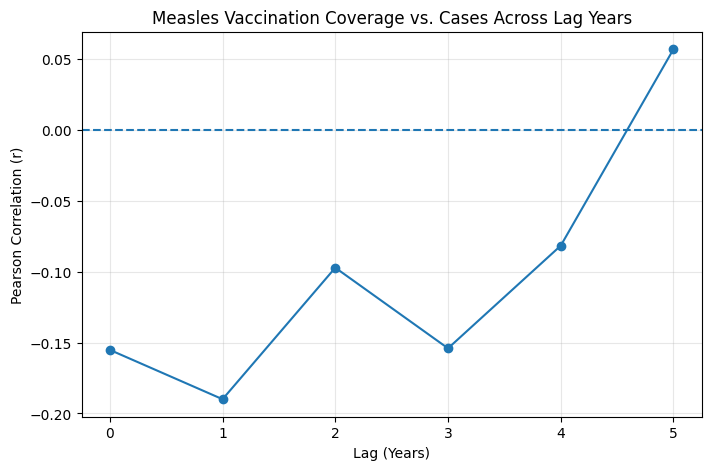

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    lag_results_df["lag_years"],
    lag_results_df["pearson_r"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Lag (Years)")
plt.ylabel("Pearson Correlation (r)")
plt.title("Measles Vaccination Coverage vs. Cases Across Lag Years")

plt.xticks(lag_results_df["lag_years"])
plt.grid(alpha=0.3)

plt.show()

The strongest negative association was observed at the 1-year lag (r = −0.190). Associations weakened at longer lags, although available state-year observations also decreased substantially with increasing lag.